# Rossmann Retail Sales Forecasting & FP&A Analytics
## 04 — Baseline Models and Validation Metrics

### Phase objective

This notebook establishes reproducible forecasting benchmarks before model optimisation.

The analysis compares:

1. simple historical averages;
2. store-aware historical averages;
3. linear models with one-hot encoded categories;
4. gradient boosting with target-encoded categories;
5. direct `Sales` modelling versus `log1p(Sales)` modelling.

### Evaluation rules

- The temporal validation horizon is the final 48 days of the historical data.
- The principal score uses the 856 stores included in the Kaggle test set.
- The sales models are fitted only on open-store observations.
- Closed stores receive a final prediction of zero.
- RMSPE excludes rows where actual sales are zero, because percentage errors are undefined for those rows.
- `Customers` is never used as a predictor.

> Stop after the final review section. Do not commit the notebook until the results have been checked.

## 1. Imports and project paths

The notebook reuses the feature pipeline created in Phase 3 and imports the forecasting metrics from `src/metrics.py`.

In [1]:
from pathlib import Path
from time import perf_counter
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    TargetEncoder,
)

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.11.15
pandas: 2.3.3
NumPy: 2.4.6
scikit-learn: 1.9.0


In [2]:
def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Project root not found. Confirm that data/ and notebooks/ exist."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    MODEL_CATEGORICAL_FEATURES,
    MODEL_FEATURES,
    MODEL_NUMERIC_FEATURES,
    build_feature_table,
)
from src.metrics import evaluate_regression, rmspe

print(f"Project root: {PROJECT_ROOT}")
print(f"Model features: {len(MODEL_FEATURES)}")
print(f"- Numeric: {len(MODEL_NUMERIC_FEATURES)}")
print(f"- Categorical: {len(MODEL_CATEGORICAL_FEATURES)}")

Project root: C:\Users\koldo\Desktop\Máster de DATA Science con IA\PROYECTO\rossmann-sales-forecasting
Model features: 34
- Numeric: 29
- Categorical: 5


## 2. Rebuild the feature tables

The notebook starts from the raw files and applies the same deterministic feature function to train and test.

This makes the modelling workflow reproducible and independent of notebook state from earlier phases.

In [3]:
train = pd.read_csv(
    RAW_DATA_DIR / "train.csv",
    low_memory=False,
)
test = pd.read_csv(
    RAW_DATA_DIR / "test.csv",
    low_memory=False,
)
store = pd.read_csv(
    RAW_DATA_DIR / "store.csv",
    low_memory=False,
)

train_features = build_feature_table(
    train,
    store,
    dataset_name="train",
)

test_features = build_feature_table(
    test,
    store,
    dataset_name="test",
)

feature_overview = pd.DataFrame(
    {
        "dataset": ["train_features", "test_features"],
        "rows": [len(train_features), len(test_features)],
        "columns": [
            train_features.shape[1],
            test_features.shape[1],
        ],
        "stores": [
            train_features["Store"].nunique(),
            test_features["Store"].nunique(),
        ],
        "minimum_date": [
            train_features["Date"].min(),
            test_features["Date"].min(),
        ],
        "maximum_date": [
            train_features["Date"].max(),
            test_features["Date"].max(),
        ],
    }
)

display(feature_overview)

,dataset,rows,columns,stores,minimum_date,maximum_date
0,train_features,1017209,47,1115,2013-01-01,2015-07-31
1,test_features,41088,46,856,2015-08-01,2015-09-17


## 3. Recreate the 48-day temporal split

The validation period exactly matches the length and store population of the Kaggle test set.

In [4]:
test_horizon_days = test_features["Date"].nunique()
validation_end = train_features["Date"].max()
validation_start = (
    validation_end
    - pd.Timedelta(days=test_horizon_days - 1)
)

train_period = train_features.loc[
    train_features["Date"] < validation_start
].copy()

validation_all_stores = train_features.loc[
    train_features["Date"].between(
        validation_start,
        validation_end,
    )
].copy()

test_store_ids = set(test_features["Store"].unique())

validation = validation_all_stores.loc[
    validation_all_stores["Store"].isin(test_store_ids)
].copy()

training_open = train_period.loc[
    train_period["OpenFilled"] == 1
].copy()

validation_open = validation.loc[
    validation["OpenFilled"] == 1
].copy()

split_summary = pd.DataFrame(
    {
        "split": [
            "training_all_rows",
            "training_open_rows",
            "validation_all_rows",
            "validation_open_rows",
            "kaggle_test",
        ],
        "rows": [
            len(train_period),
            len(training_open),
            len(validation),
            len(validation_open),
            len(test_features),
        ],
        "unique_dates": [
            train_period["Date"].nunique(),
            training_open["Date"].nunique(),
            validation["Date"].nunique(),
            validation_open["Date"].nunique(),
            test_features["Date"].nunique(),
        ],
        "stores": [
            train_period["Store"].nunique(),
            training_open["Store"].nunique(),
            validation["Store"].nunique(),
            validation_open["Store"].nunique(),
            test_features["Store"].nunique(),
        ],
        "minimum_date": [
            train_period["Date"].min(),
            training_open["Date"].min(),
            validation["Date"].min(),
            validation_open["Date"].min(),
            test_features["Date"].min(),
        ],
        "maximum_date": [
            train_period["Date"].max(),
            training_open["Date"].max(),
            validation["Date"].max(),
            validation_open["Date"].max(),
            test_features["Date"].max(),
        ],
    }
)

display(split_summary)

assert validation["Date"].nunique() == test_horizon_days
assert validation["Store"].nunique() == test_features["Store"].nunique()
assert len(validation) == len(test_features)
assert train_period["Date"].max() < validation["Date"].min()

,split,rows,unique_dates,stores,minimum_date,maximum_date
0,training_all_rows,963689,894,1115,2013-01-01,2015-06-13
1,training_open_rows,798508,894,1115,2013-01-01,2015-06-13
2,validation_all_rows,41088,48,856,2015-06-14,2015-07-31
3,validation_open_rows,35262,48,856,2015-06-14,2015-07-31
4,kaggle_test,41088,48,856,2015-08-01,2015-09-17


## 4. Evaluation table and prediction container

Every model produces a prediction for all 41,088 validation rows.

The model estimates sales only for open stores. Closed stores are assigned zero.

In [5]:
validation_predictions = validation[
    [
        "Store",
        "Date",
        "DayOfWeek",
        "Promo",
        "SchoolHoliday",
        "StateHoliday",
        "StoreType",
        "Assortment",
        "OpenFilled",
        "Sales",
    ]
].copy()

model_results = []

print(
    "Validation rows with positive actual sales: "
    f"{(validation_predictions['Sales'] > 0).sum():,}"
)
print(
    "Validation closed rows: "
    f"{(validation_predictions['OpenFilled'] == 0).sum():,}"
)

Validation rows with positive actual sales: 35,262
Validation closed rows: 5,826


## 5. Historical-average baselines

These benchmarks use only information from the training period.

The hierarchy becomes gradually more specific:

1. global mean of open-store sales;
2. store mean;
3. store and weekday mean;
4. store, weekday, and standard-promotion mean.

When a detailed combination is unavailable, the prediction falls back to the preceding level.

In [6]:
global_open_mean = training_open["Sales"].mean()

store_mean_map = (
    training_open.groupby("Store")["Sales"]
    .mean()
)

store_weekday_mean_map = (
    training_open.groupby(
        ["Store", "DayOfWeek"]
    )["Sales"]
    .mean()
)

store_weekday_promo_mean_map = (
    training_open.groupby(
        ["Store", "DayOfWeek", "Promo"]
    )["Sales"]
    .mean()
)


def mapped_prediction(
    dataframe: pd.DataFrame,
    *,
    mapping: pd.Series,
    keys: list[str],
    fallback_store: bool = True,
) -> pd.Series:
    """Map a grouped historical average with a documented fallback."""
    mapped_index = pd.MultiIndex.from_frame(
        dataframe[keys]
    )

    prediction = pd.Series(
        mapped_index.map(mapping),
        index=dataframe.index,
        dtype=float,
    )

    if fallback_store:
        prediction = prediction.fillna(
            dataframe["Store"].map(store_mean_map)
        )

    return prediction.fillna(global_open_mean)


def complete_open_closed_prediction(
    open_prediction: pd.Series,
) -> np.ndarray:
    """Return full validation predictions with zero assigned to closed stores."""
    full_prediction = pd.Series(
        0.0,
        index=validation.index,
    )

    full_prediction.loc[validation_open.index] = (
        np.clip(
            open_prediction.loc[validation_open.index],
            a_min=0,
            a_max=None,
        )
    )

    return full_prediction.to_numpy()


global_open_prediction = pd.Series(
    global_open_mean,
    index=validation_open.index,
)

validation_predictions["pred_global_open_mean"] = (
    complete_open_closed_prediction(
        global_open_prediction
    )
)

store_prediction = (
    validation_open["Store"]
    .map(store_mean_map)
    .fillna(global_open_mean)
)

validation_predictions["pred_store_mean"] = (
    complete_open_closed_prediction(
        store_prediction
    )
)

store_weekday_prediction = mapped_prediction(
    validation_open,
    mapping=store_weekday_mean_map,
    keys=["Store", "DayOfWeek"],
)

validation_predictions["pred_store_weekday_mean"] = (
    complete_open_closed_prediction(
        store_weekday_prediction
    )
)

store_weekday_promo_prediction = mapped_prediction(
    validation_open,
    mapping=store_weekday_promo_mean_map,
    keys=["Store", "DayOfWeek", "Promo"],
)

validation_predictions[
    "pred_store_weekday_promo_mean"
] = complete_open_closed_prediction(
    store_weekday_promo_prediction
)

baseline_prediction_columns = {
    "Global open-store mean": "pred_global_open_mean",
    "Store mean": "pred_store_mean",
    "Store + weekday mean": "pred_store_weekday_mean",
    "Store + weekday + Promo mean": (
        "pred_store_weekday_promo_mean"
    ),
}

for model_name, prediction_column in baseline_prediction_columns.items():
    model_results.append(
        evaluate_regression(
            validation_predictions["Sales"],
            validation_predictions[prediction_column],
            model_name=model_name,
            fit_seconds=0.0,
        )
    )

baseline_results = (
    pd.concat(
        model_results,
        ignore_index=True,
    )
    .sort_values("rmspe")
)

display(baseline_results)

,model,rmspe,mae,rmse,wape,bias_pct,evaluation_rows,positive_actual_rows,fit_seconds
3,Store + weekday + Promo mean,0.1449,648.1436,"1,025.3594",0.1068,-2.3790,41088,35262,0.0000
2,Store + weekday mean,0.2278,"1,080.7125","1,541.6310",0.1780,-3.1606,41088,35262,0.0000
1,Store mean,0.2854,"1,225.8552","1,764.9217",0.2020,-3.4666,41088,35262,0.0000
0,Global open-store mean,0.5017,"1,859.8266","2,743.0255",0.3064,-1.8118,41088,35262,0.0000


## 6. Ridge regression with one-hot encoded categories

Ridge provides a transparent linear machine-learning benchmark.

- Numeric variables are standardised.
- Categorical variables, including `Store`, are one-hot encoded.
- The model is trained only on open-store rows.
- Negative predictions are clipped to zero.

Two targets are compared:

1. raw `Sales`;
2. `log1p(Sales)`, transformed back with `expm1`.

In [7]:
def build_ridge_pipeline() -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                StandardScaler(
                    with_mean=False,
                ),
                MODEL_NUMERIC_FEATURES,
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=True,
                ),
                MODEL_CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        sparse_threshold=0.30,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                Ridge(
                    alpha=10.0,
                    solver="lsqr",
                    max_iter=2_000,
                    tol=1e-3,
                ),
            ),
        ]
    )

In [8]:
ridge_direct = build_ridge_pipeline()

ridge_direct_start = perf_counter()

ridge_direct.fit(
    training_open[MODEL_FEATURES],
    training_open["Sales"],
)

ridge_direct_fit_seconds = (
    perf_counter() - ridge_direct_start
)

ridge_direct_open_prediction = pd.Series(
    np.clip(
        ridge_direct.predict(
            validation_open[MODEL_FEATURES]
        ),
        a_min=0,
        a_max=None,
    ),
    index=validation_open.index,
)

validation_predictions["pred_ridge_direct"] = (
    complete_open_closed_prediction(
        ridge_direct_open_prediction
    )
)

model_results.append(
    evaluate_regression(
        validation_predictions["Sales"],
        validation_predictions["pred_ridge_direct"],
        model_name="Ridge — direct Sales",
        fit_seconds=ridge_direct_fit_seconds,
    )
)

print(
    "Ridge direct fit time: "
    f"{ridge_direct_fit_seconds:,.1f} seconds"
)

Ridge direct fit time: 6.1 seconds


In [9]:
ridge_log = TransformedTargetRegressor(
    regressor=build_ridge_pipeline(),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)

ridge_log_start = perf_counter()

ridge_log.fit(
    training_open[MODEL_FEATURES],
    training_open["Sales"],
)

ridge_log_fit_seconds = (
    perf_counter() - ridge_log_start
)

ridge_log_open_prediction = pd.Series(
    np.clip(
        ridge_log.predict(
            validation_open[MODEL_FEATURES]
        ),
        a_min=0,
        a_max=None,
    ),
    index=validation_open.index,
)

validation_predictions["pred_ridge_log"] = (
    complete_open_closed_prediction(
        ridge_log_open_prediction
    )
)

model_results.append(
    evaluate_regression(
        validation_predictions["Sales"],
        validation_predictions["pred_ridge_log"],
        model_name="Ridge — log1p Sales",
        fit_seconds=ridge_log_fit_seconds,
    )
)

print(
    "Ridge log-target fit time: "
    f"{ridge_log_fit_seconds:,.1f} seconds"
)

ridge_results = (
    pd.concat(
        model_results,
        ignore_index=True,
    )
    .sort_values("rmspe")
)

display(ridge_results)

Ridge log-target fit time: 6.1 seconds


,model,rmspe,mae,rmse,wape,bias_pct,evaluation_rows,positive_actual_rows,fit_seconds
3,Store + weekday + Promo mean,0.1449,648.1436,"1,025.3594",0.1068,-2.3790,41088,35262,0.0000
5,Ridge — log1p Sales,0.1825,782.7562,"1,225.1918",0.1290,-2.3695,41088,35262,6.0821
4,Ridge — direct Sales,0.1965,816.4878,"1,238.6656",0.1345,-2.3567,41088,35262,6.0796
2,Store + weekday mean,0.2278,"1,080.7125","1,541.6310",0.1780,-3.1606,41088,35262,0.0000
1,Store mean,0.2854,"1,225.8552","1,764.9217",0.2020,-3.4666,41088,35262,0.0000
0,Global open-store mean,0.5017,"1,859.8266","2,743.0255",0.3064,-1.8118,41088,35262,0.0000


## 7. Histogram gradient boosting with target-encoded categories

This nonlinear benchmark can learn interactions such as:

- store × promotion;
- store type × calendar;
- competition age × store profile;
- nonlinear seasonal effects.

Target encoding reduces the five categorical fields to compact numeric features. The encoder is fitted only on the training period and uses internal cross-fitting to reduce target leakage.

Both direct and log-transformed targets are evaluated.

In [10]:
def build_hgb_pipeline() -> Pipeline:
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                "passthrough",
                MODEL_NUMERIC_FEATURES,
            ),
            (
                "categorical",
                TargetEncoder(
                    target_type="continuous",
                    smooth="auto",
                    cv=5,
                    shuffle=True,
                    random_state=42,
                ),
                MODEL_CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    regressor = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=50,
        l2_regularization=1.0,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=20,
        random_state=42,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", regressor),
        ]
    )

In [11]:
hgb_direct = build_hgb_pipeline()

hgb_direct_start = perf_counter()

hgb_direct.fit(
    training_open[MODEL_FEATURES],
    training_open["Sales"],
)

hgb_direct_fit_seconds = (
    perf_counter() - hgb_direct_start
)

hgb_direct_open_prediction = pd.Series(
    np.clip(
        hgb_direct.predict(
            validation_open[MODEL_FEATURES]
        ),
        a_min=0,
        a_max=None,
    ),
    index=validation_open.index,
)

validation_predictions["pred_hgb_direct"] = (
    complete_open_closed_prediction(
        hgb_direct_open_prediction
    )
)

model_results.append(
    evaluate_regression(
        validation_predictions["Sales"],
        validation_predictions["pred_hgb_direct"],
        model_name="Target encoding + HGB — direct Sales",
        fit_seconds=hgb_direct_fit_seconds,
    )
)

print(
    "HGB direct fit time: "
    f"{hgb_direct_fit_seconds:,.1f} seconds"
)
print(
    "HGB direct iterations: "
    f"{hgb_direct.named_steps['regressor'].n_iter_}"
)

HGB direct fit time: 14.8 seconds
HGB direct iterations: 250


In [12]:
hgb_log = TransformedTargetRegressor(
    regressor=build_hgb_pipeline(),
    func=np.log1p,
    inverse_func=np.expm1,
    check_inverse=False,
)

hgb_log_start = perf_counter()

hgb_log.fit(
    training_open[MODEL_FEATURES],
    training_open["Sales"],
)

hgb_log_fit_seconds = (
    perf_counter() - hgb_log_start
)

hgb_log_open_prediction = pd.Series(
    np.clip(
        hgb_log.predict(
            validation_open[MODEL_FEATURES]
        ),
        a_min=0,
        a_max=None,
    ),
    index=validation_open.index,
)

validation_predictions["pred_hgb_log"] = (
    complete_open_closed_prediction(
        hgb_log_open_prediction
    )
)

model_results.append(
    evaluate_regression(
        validation_predictions["Sales"],
        validation_predictions["pred_hgb_log"],
        model_name="Target encoding + HGB — log1p Sales",
        fit_seconds=hgb_log_fit_seconds,
    )
)

print(
    "HGB log-target fit time: "
    f"{hgb_log_fit_seconds:,.1f} seconds"
)
print(
    "HGB log-target iterations: "
    f"{hgb_log.regressor_.named_steps['regressor'].n_iter_}"
)

HGB log-target fit time: 14.9 seconds
HGB log-target iterations: 250


## 8. Compare all models

RMSPE is the primary ranking metric. MAE, RMSE, WAPE, and aggregate bias provide complementary business interpretation.

In [13]:
model_results_table = (
    pd.concat(
        model_results,
        ignore_index=True,
    )
    .drop_duplicates(
        subset="model",
        keep="last",
    )
    .sort_values(
        "rmspe",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(model_results_table)

best_model_name = model_results_table.loc[
    0,
    "model",
]

prediction_column_lookup = {
    "Global open-store mean": "pred_global_open_mean",
    "Store mean": "pred_store_mean",
    "Store + weekday mean": "pred_store_weekday_mean",
    "Store + weekday + Promo mean": (
        "pred_store_weekday_promo_mean"
    ),
    "Ridge — direct Sales": "pred_ridge_direct",
    "Ridge — log1p Sales": "pred_ridge_log",
    "Target encoding + HGB — direct Sales": (
        "pred_hgb_direct"
    ),
    "Target encoding + HGB — log1p Sales": (
        "pred_hgb_log"
    ),
}

best_prediction_column = prediction_column_lookup[
    best_model_name
]

validation_predictions["best_prediction"] = (
    validation_predictions[best_prediction_column]
)

print(f"Best validation model: {best_model_name}")
print(
    "Best RMSPE: "
    f"{model_results_table.loc[0, 'rmspe']:.4f}"
)

,model,rmspe,mae,rmse,wape,bias_pct,evaluation_rows,positive_actual_rows,fit_seconds
0,Store + weekday + Promo mean,0.1449,648.1436,"1,025.3594",0.1068,-2.3790,41088,35262,0.0000
1,Target encoding + HGB — log1p Sales,0.1661,704.5621,"1,067.9673",0.1161,-0.0165,41088,35262,14.9342
2,Target encoding + HGB — direct Sales,0.1791,713.7495,"1,074.3160",0.1176,1.4269,41088,35262,14.8313
3,Ridge — log1p Sales,0.1825,782.7562,"1,225.1918",0.1290,-2.3695,41088,35262,6.0821
4,Ridge — direct Sales,0.1965,816.4878,"1,238.6656",0.1345,-2.3567,41088,35262,6.0796
5,Store + weekday mean,0.2278,"1,080.7125","1,541.6310",0.1780,-3.1606,41088,35262,0.0000
6,Store mean,0.2854,"1,225.8552","1,764.9217",0.2020,-3.4666,41088,35262,0.0000
7,Global open-store mean,0.5017,"1,859.8266","2,743.0255",0.3064,-1.8118,41088,35262,0.0000


Best validation model: Store + weekday + Promo mean
Best RMSPE: 0.1449


## 9. Diagnostic results for the best model

The group diagnostics show whether the selected model behaves consistently across weekdays, promotion status, and store formats.

In [14]:
def grouped_diagnostics(
    dataframe: pd.DataFrame,
    *,
    group_columns: list[str],
) -> pd.DataFrame:
    rows = []

    group_key = (
        group_columns[0]
        if len(group_columns) == 1
        else group_columns
    )

    for group_values, group_data in dataframe.groupby(
        group_key,
        dropna=False,
    ):
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        actual = group_data["Sales"].to_numpy()
        predicted = group_data["best_prediction"].to_numpy()

        valid_rmspe_rows = actual != 0

        row = {
            column: value
            for column, value in zip(
                group_columns,
                group_values,
            )
        }

        row.update(
            {
                "rows": len(group_data),
                "actual_sales": actual.sum(),
                "predicted_sales": predicted.sum(),
                "rmspe": (
                    rmspe(
                        actual[valid_rmspe_rows],
                        predicted[valid_rmspe_rows],
                    )
                    if valid_rmspe_rows.any()
                    else np.nan
                ),
                "mean_actual": actual.mean(),
                "mean_prediction": predicted.mean(),
                "bias_pct": (
                    (
                        predicted.sum() - actual.sum()
                    )
                    / actual.sum()
                    * 100
                    if actual.sum() != 0
                    else np.nan
                ),
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)


weekday_diagnostics = grouped_diagnostics(
    validation_predictions,
    group_columns=["DayOfWeek"],
)

promo_diagnostics = grouped_diagnostics(
    validation_predictions,
    group_columns=["Promo"],
)

store_format_diagnostics = grouped_diagnostics(
    validation_predictions,
    group_columns=["StoreType", "Assortment"],
)

display(weekday_diagnostics)
display(promo_diagnostics)
display(store_format_diagnostics)

,DayOfWeek,rows,actual_sales,predicted_sales,rmspe,mean_actual,mean_prediction,bias_pct
0,1,5992,50159856,"47,877,632.9273",0.1407,"8,371.1375","7,990.2592",-4.5499
1,2,5992,44264845,"41,625,365.3666",0.1414,"7,387.3239","6,946.8233",-5.9629
2,3,5992,40850675,"39,756,237.6029",0.1297,"6,817.5359","6,634.8861",-2.6791
3,4,5992,40532226,"39,646,671.1178",0.1293,"6,764.3902","6,616.6007",-2.1848
4,5,5992,42152721,"42,109,749.3269",0.1515,"7,034.8333","7,027.6618",-0.1019
5,6,5136,29875079,"31,118,916.6397",0.1731,"5,816.7989","6,058.9791",4.1635
6,7,5992,1564000,"1,331,669.8948",0.2272,261.0147,222.2413,-14.8549


,Promo,rows,actual_sales,predicted_sales,rmspe,mean_actual,mean_prediction,bias_pct
0,0,23968,106916606,"106,631,359.2673",0.1474,"4,460.8063","4,448.9052",-0.2668
1,1,17120,142482796,"136,834,883.6087",0.1422,"8,322.5932","7,992.6918",-3.9639


,StoreType,Assortment,rows,actual_sales,predicted_sales,rmspe,mean_actual,mean_prediction,bias_pct
0,a,a,12672,69740851,"70,487,119.8394",0.1490,"5,503.5394","5,562.4305",1.0701
1,a,c,9456,63057647,"61,159,000.0048",0.1526,"6,668.5329","6,467.7453",-3.0110
2,b,a,96,1689925,"1,650,149.1937",0.0900,"17,603.3854","17,189.0541",-2.3537
3,b,b,432,4225473,"3,691,518.5367",0.1817,"9,781.1875","8,545.1818",-12.6366
4,b,c,48,839860,"872,376.5348",0.0796,"17,497.0833","18,174.5111",3.8717
5,c,a,2160,12403421,"12,269,325.8888",0.1363,"5,742.3245","5,680.2435",-1.0811
6,c,c,2112,11892903,"11,538,120.4588",0.1571,"5,631.1094","5,463.1252",-2.9831
7,d,a,5376,30265995,"29,749,823.0334",0.1343,"5,629.8354","5,533.8212",-1.7055
8,d,c,8736,55283327,"52,048,809.3855",0.1336,"6,328.2197","5,957.9681",-5.8508


## 10. Daily actual-versus-predicted comparison

Aggregating by date reveals whether the selected model captures the overall sales trajectory and promotional peaks.

In [15]:
daily_validation_predictions = (
    validation_predictions.groupby(
        "Date",
        as_index=False,
    )
    .agg(
        actual_sales=("Sales", "sum"),
        predicted_sales=("best_prediction", "sum"),
        reporting_stores=("Store", "nunique"),
        open_stores=("OpenFilled", "sum"),
    )
)

daily_validation_predictions["absolute_error"] = (
    daily_validation_predictions["predicted_sales"]
    - daily_validation_predictions["actual_sales"]
).abs()

display(daily_validation_predictions.head())
display(daily_validation_predictions.tail())

,Date,actual_sales,predicted_sales,reporting_stores,open_stores,absolute_error
0,2015-06-14,219309,"189,746.0938",856,27,"29,562.9062"
1,2015-06-15,8698635,"8,091,504.3417",856,855,"607,130.6583"
2,2015-06-16,7273996,"6,839,790.2850",856,855,"434,205.7150"
3,2015-06-17,6533120,"6,418,133.3720",856,855,"114,986.6280"
4,2015-06-18,6194895,"6,333,483.9969",856,855,"138,588.9969"


,Date,actual_sales,predicted_sales,reporting_stores,open_stores,absolute_error
43,2015-07-27,8121049,"8,098,718.9644",856,856,"22,330.0356"
44,2015-07-28,6917617,"6,845,819.0926",856,856,"71,797.9074"
45,2015-07-29,6488169,"6,423,411.6989",856,856,"64,757.3011"
46,2015-07-30,6729611,"6,338,386.2260",856,856,"391,224.7740"
47,2015-07-31,7757358,"6,531,628.3663",856,856,"1,225,729.6337"


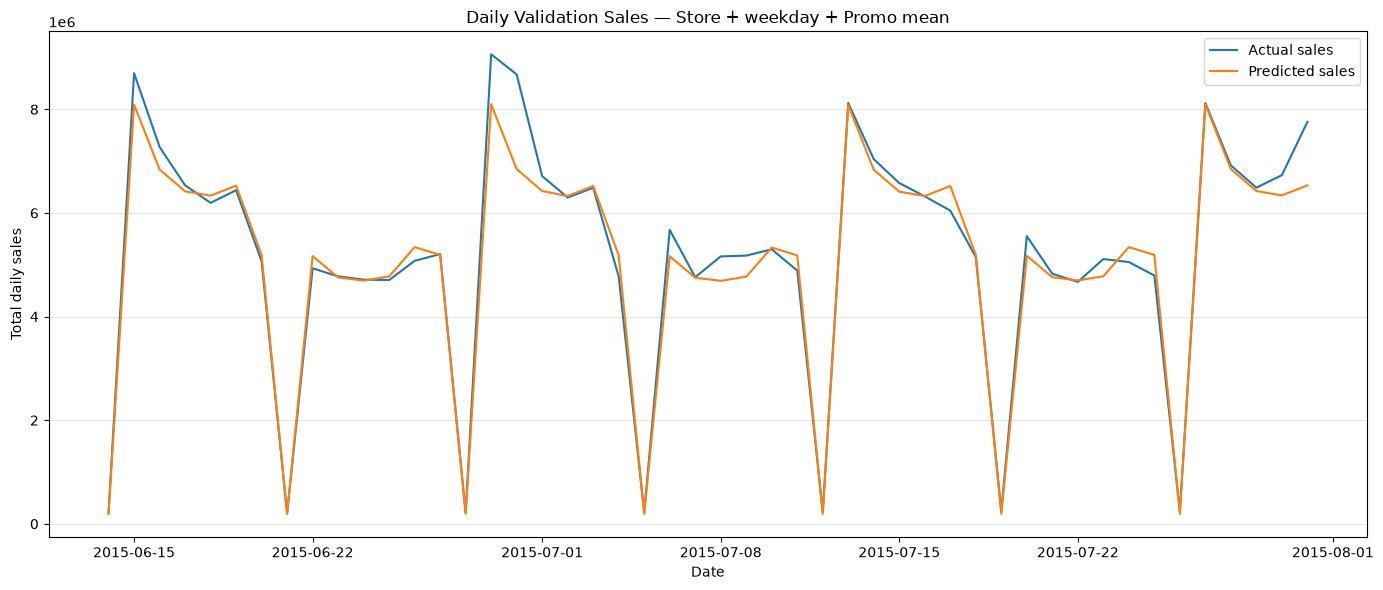

In [16]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    daily_validation_predictions["Date"],
    daily_validation_predictions["actual_sales"],
    label="Actual sales",
)

ax.plot(
    daily_validation_predictions["Date"],
    daily_validation_predictions["predicted_sales"],
    label="Predicted sales",
)

ax.set_title(
    f"Daily Validation Sales — {best_model_name}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Total daily sales")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()

daily_prediction_figure_path = (
    REPORT_FIGURES_DIR
    / "baseline_daily_actual_vs_predicted.png"
)

fig.savefig(
    daily_prediction_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

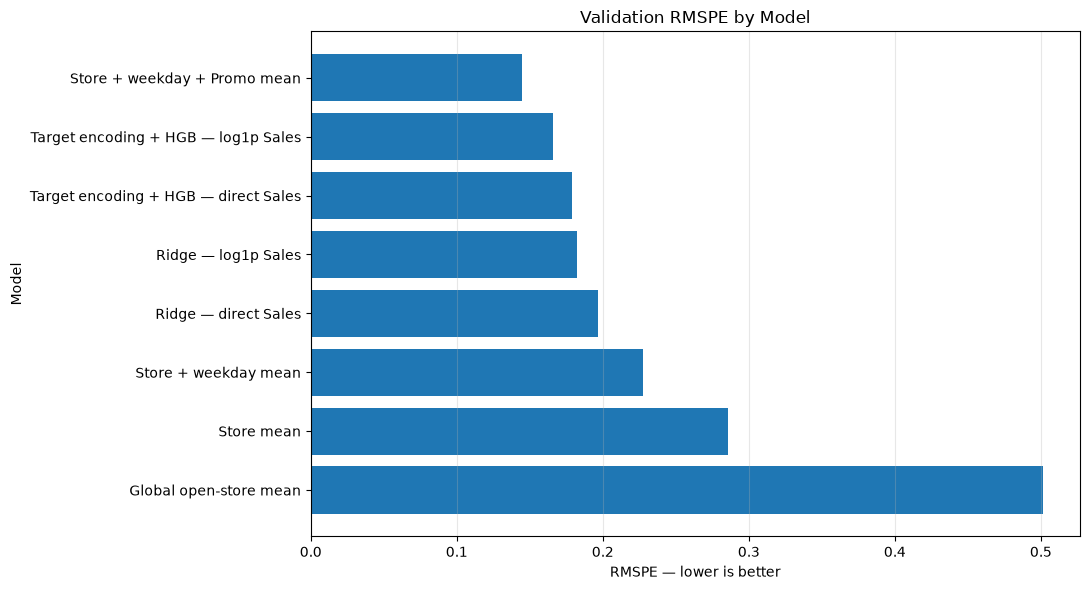

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_results = model_results_table.sort_values(
    "rmspe",
    ascending=False,
)

ax.barh(
    plot_results["model"],
    plot_results["rmspe"],
)

ax.set_title("Validation RMSPE by Model")
ax.set_xlabel("RMSPE — lower is better")
ax.set_ylabel("Model")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()

model_comparison_figure_path = (
    REPORT_FIGURES_DIR
    / "baseline_model_rmspe_comparison.png"
)

fig.savefig(
    model_comparison_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## 11. Save compact model results

The fitted model objects are not saved yet. Model persistence will be decided after the benchmark results and diagnostics have been reviewed.

In [18]:
REPORT_TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
REPORT_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

model_results_path = (
    REPORT_TABLES_DIR
    / "baseline_model_results.csv"
)

validation_predictions_path = (
    REPORT_TABLES_DIR
    / "baseline_validation_predictions.csv"
)

daily_predictions_path = (
    REPORT_TABLES_DIR
    / "baseline_daily_predictions.csv"
)

weekday_diagnostics_path = (
    REPORT_TABLES_DIR
    / "baseline_weekday_diagnostics.csv"
)

promo_diagnostics_path = (
    REPORT_TABLES_DIR
    / "baseline_promo_diagnostics.csv"
)

store_format_diagnostics_path = (
    REPORT_TABLES_DIR
    / "baseline_store_format_diagnostics.csv"
)

model_results_table.to_csv(
    model_results_path,
    index=False,
)

validation_predictions.to_csv(
    validation_predictions_path,
    index=False,
)

daily_validation_predictions.to_csv(
    daily_predictions_path,
    index=False,
)

weekday_diagnostics.to_csv(
    weekday_diagnostics_path,
    index=False,
)

promo_diagnostics.to_csv(
    promo_diagnostics_path,
    index=False,
)

store_format_diagnostics.to_csv(
    store_format_diagnostics_path,
    index=False,
)

print("Saved:")
print(f"- {model_results_path.relative_to(PROJECT_ROOT)}")
print(f"- {validation_predictions_path.relative_to(PROJECT_ROOT)}")
print(f"- {daily_predictions_path.relative_to(PROJECT_ROOT)}")
print(f"- {weekday_diagnostics_path.relative_to(PROJECT_ROOT)}")
print(f"- {promo_diagnostics_path.relative_to(PROJECT_ROOT)}")
print(f"- {store_format_diagnostics_path.relative_to(PROJECT_ROOT)}")
print(f"- {daily_prediction_figure_path.relative_to(PROJECT_ROOT)}")
print(f"- {model_comparison_figure_path.relative_to(PROJECT_ROOT)}")

Saved:
- reports\tables\baseline_model_results.csv
- reports\tables\baseline_validation_predictions.csv
- reports\tables\baseline_daily_predictions.csv
- reports\tables\baseline_weekday_diagnostics.csv
- reports\tables\baseline_promo_diagnostics.csv
- reports\tables\baseline_store_format_diagnostics.csv
- reports\figures\baseline_daily_actual_vs_predicted.png
- reports\figures\baseline_model_rmspe_comparison.png


## Stop and review

Share the following results before committing:

1. `baseline_results`
2. `ridge_results`
3. The fit time for both Ridge models
4. The fit time and iteration count for both HGB models
5. `model_results_table`
6. The name and RMSPE of the best model
7. `weekday_diagnostics`
8. `promo_diagnostics`
9. `store_format_diagnostics`
10. The daily actual-versus-predicted chart
11. The RMSPE comparison chart
12. Any warning or error

### Decisions to make after review

- Which benchmark becomes the first modelling reference?
- Does `log1p(Sales)` improve Ridge and gradient boosting?
- Does the nonlinear model materially outperform the historical averages?
- Are there weekdays, promotion states, or formats with weak performance?
- Should the next phase optimise the best sklearn model or add a specialised boosting library?
- Should the best model be retrained on all historical open-store rows and used for the Kaggle test prediction?